In [1]:
%load_ext autoreload
%autoreload 2
import discovery as ds
from pathlib import Path
import simulation_utils as su
from pt_bubble import spectrum
import numpy as np
import matplotlib.pyplot as plt
import jax
import json

## Load data

In [2]:
discovery_psr_dir = Path.home() / "Dropbox" / "Documents" / "research" / "nanograv"/ "codes" / "discovery"/"data"
psrs = su.load_pulsars(discovery_psr_dir)

Text(0, 0.5, '$S(f)$ [s$^3$]')

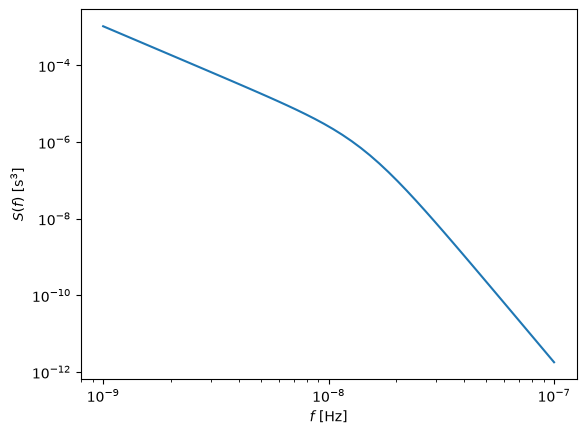

In [4]:
IRN_N_FREQS = 30
GW_N_FREQS = 14
GW_ARGNAMES = ["log10_alpha", "log10_T_star", "log10_H_R", "a", "b", "c"]
pars = (0.74, -0.89, -0.2, 2.5, 2, 1.2)
gw_dict = dict(zip(map(lambda x: "gw_"+ x, GW_ARGNAMES), pars))

# Spectral shape: pass df=1 to get the bare PSD in s^3.
f = np.logspace(-9, -7)
plt.loglog(f, spectrum(f, 1.0, *pars))
plt.xlabel("$f$ [Hz]")
plt.ylabel("$S(f)$ [s$^3$]")

Text(0, 0.5, '$S(f)\\,\\Delta f$ [s$^2$]')

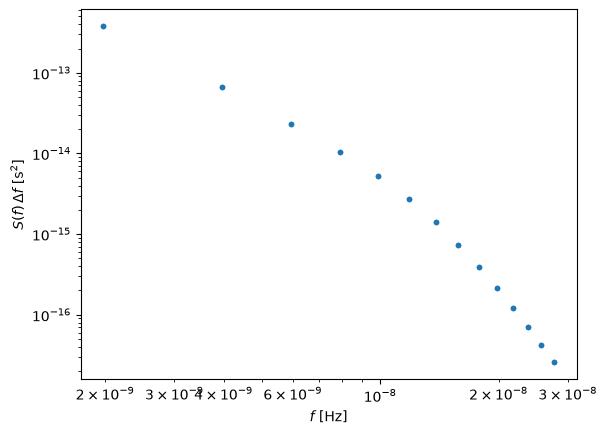

In [5]:
t_span = ds.getspan(psrs)
f_c = np.arange(1, GW_N_FREQS + 1) / t_span
f_b = np.repeat(f_c, 2)
df_b = np.repeat(np.diff(np.concatenate(([0], f_c))), 2)

plt.loglog(f_b, spectrum(f_b, df_b, *pars), ".")
plt.xlabel("$f$ [Hz]")
plt.ylabel(r"$S(f)\,\Delta f$ [s$^2$]")

## Sample residuals from likelihood object

In [6]:
with jax.default_device("cpu"):
    curn_logl = su.build_likelihood_for_sampling(
        psrs,
        spectrum,
        GW_ARGNAMES,
        irn_n_freqs=IRN_N_FREQS,
        gw_n_freqs=GW_N_FREQS,
    )
    curn_logl.logL.params

In [7]:
with (Path.cwd() / "max-likelihood-estimate.json").open("r") as f: 
    max_like_irn_params = json.load(f)

In [9]:
key = jax.random.key(117)
_, sim_residuals = curn_logl.sample(key, gw_dict | max_like_irn_params)

In [11]:
for psr, residuals in zip(psrs, sim_residuals, strict=True):
    psr.residuals = np.array(residuals)
    psr.save_feather(Path("../data") / f"v1p1_sim_{psr.name}.feather")